<a href="https://colab.research.google.com/github/AysunAllahverdiyeva/Devlab-layiheler/blob/main/data_analitika_Layihe_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving supermarket_sales - Sheet1.csv to supermarket_sales - Sheet1.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('supermarket_sales - Sheet1.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'supermarket_sales - Sheet1.csv'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving supermarket_sales - Sheet1.csv to supermarket_sales - Sheet1.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('supermarket_sales - Sheet1.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
print(df.shape)
df.info()

(1000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin p

In [ ]:
print(df.isnull().sum())
print(f"\nDublikat sətir sayı: {df.duplicated().sum()}")

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Dublikat sətir sayı: 0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

df[['Date', 'Time']].head()

,Date,Time
0,2019-01-05,13:08:00
1,2019-03-08,10:29:00
2,2019-03-03,13:23:00
3,2019-01-27,20:33:00
4,2019-02-08,10:37:00


In [ ]:
df['Hour'] = df['Time'].apply(lambda t: t.hour)
df[['Time', 'Hour']].head()

,Time,Hour
0,13:08:00,13
1,10:29:00,10
2,13:23:00,13
3,20:33:00,20
4,10:37:00,10


In [ ]:
branch_summary = df.groupby('Branch')['Total'].agg(['sum', 'count'])
print("--- Filial üzrə ---")
print(branch_summary)

productline_summary = df.groupby('Product line')['Total'].agg(['sum', 'count']).sort_values('sum', ascending=False)
print("\n--- Məhsul xətti üzrə ---")
print(productline_summary)

customertype_summary = df.groupby('Customer type')['Total'].agg(['sum', 'count'])
print("\n--- Müştəri növü üzrə ---")
print(customertype_summary)

gender_summary = df.groupby('Gender')['Total'].agg(['sum', 'count'])
print("\n--- Cins üzrə ---")
print(gender_summary)

--- Filial üzrə ---
                sum  count
Branch                    
A       106200.3705    340
B       106197.6720    332
C       110568.7065    328

--- Məhsul xətti üzrə ---
                               sum  count
Product line                             
Food and beverages      56144.8440    174
Sports and travel       55122.8265    166
Electronic accessories  54337.5315    170
Fashion accessories     54305.8950    178
Home and lifestyle      53861.9130    160
Health and beauty       49193.7390    152

--- Müştəri növü üzrə ---
                      sum  count
Customer type                   
Member         164223.444    501
Normal         158743.305    499

--- Cins üzrə ---
               sum  count
Gender                   
Female  167882.925    501
Male    155083.824    499


In [ ]:
hourly_sales = df.groupby('Hour')['Total'].agg(['sum', 'count']).sort_values('count', ascending=False)
hourly_sales

,sum,count
Hour,,
19,39699.5130,113
13,34723.2270,103
15,31179.5085,102
10,31421.4810,101
18,26030.3400,93
11,30377.3295,90
12,26065.8825,89
14,30828.3990,83
16,25226.3235,77


In [ ]:
print("Ən yüksək performanslı məhsul xətti:")
print(productline_summary.head(1))

print("\nƏn aşağı performanslı məhsul xətti:")
print(productline_summary.tail(1))

Ən yüksək performanslı məhsul xətti:
                          sum  count
Product line                        
Food and beverages  56144.844    174

Ən aşağı performanslı məhsul xətti:
                         sum  count
Product line                       
Health and beauty  49193.739    152


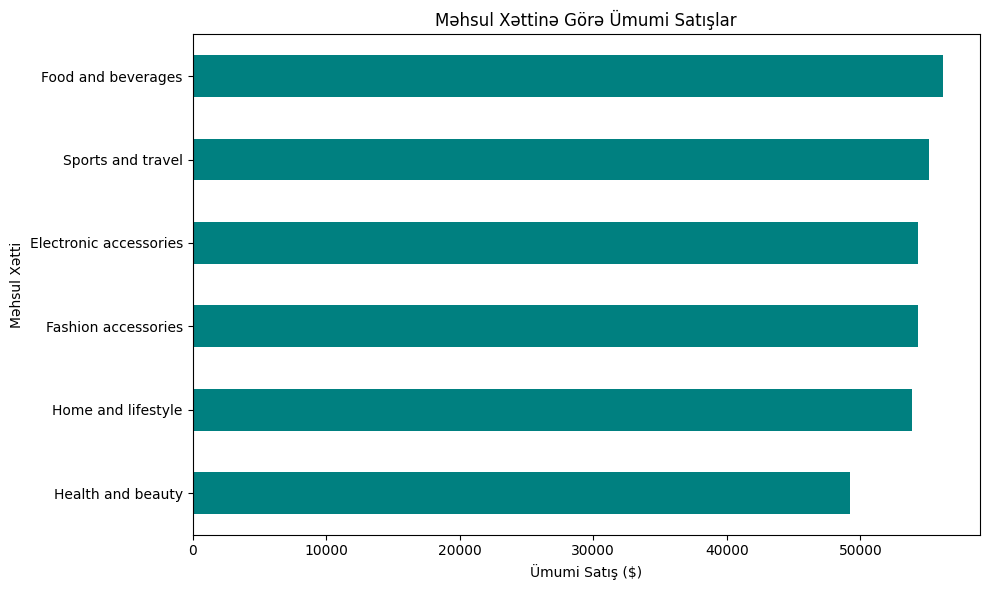

In [ ]:
plt.figure(figsize=(10,6))
productline_summary['sum'].sort_values().plot(kind='barh', color='teal')
plt.title('Məhsul Xəttinə Görə Ümumi Satışlar')
plt.xlabel('Ümumi Satış ($)')
plt.ylabel('Məhsul Xətti')
plt.tight_layout()
plt.show()

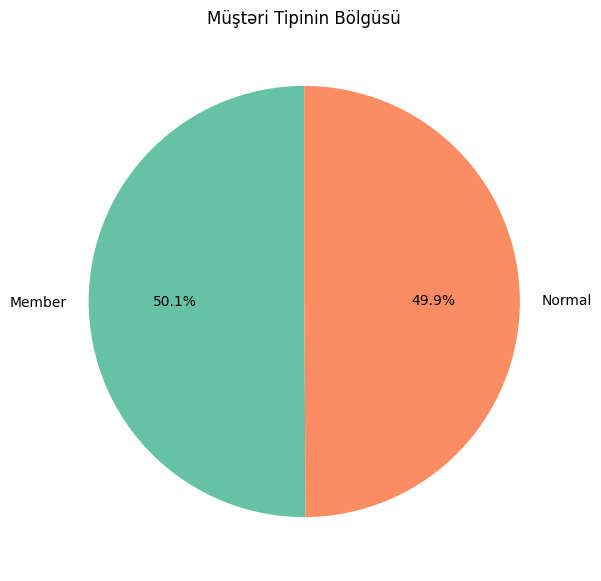

In [ ]:
customer_counts = df['Customer type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
plt.title('Müştəri Tipinin Bölgüsü')
plt.show()

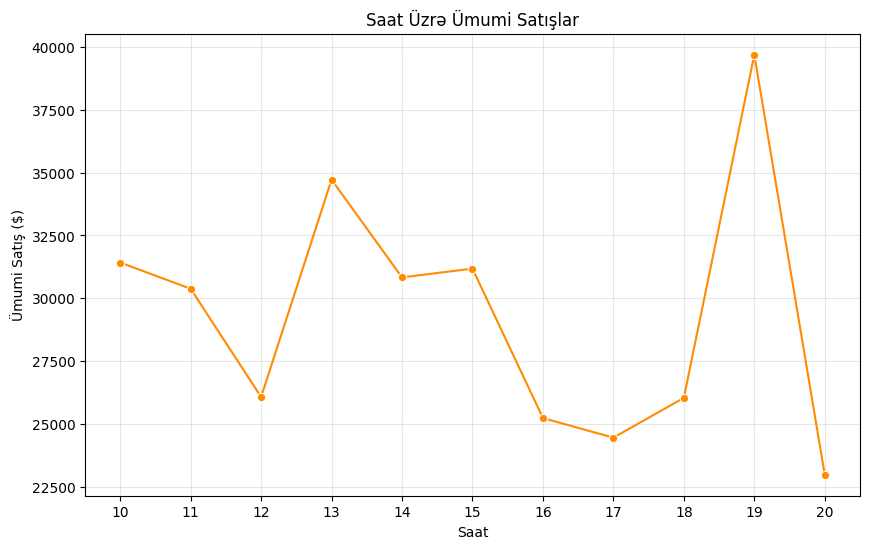

In [ ]:
hourly_sorted = df.groupby('Hour')['Total'].sum().sort_index()

plt.figure(figsize=(10,6))
sns.lineplot(x=hourly_sorted.index, y=hourly_sorted.values, marker='o', color='darkorange')
plt.title('Saat Üzrə Ümumi Satışlar')
plt.xlabel('Saat')
plt.ylabel('Ümumi Satış ($)')
plt.xticks(range(10, 21))
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
profit_by_line = df.groupby('Product line').agg(
    total_income=('gross income', 'sum'),
    total_cogs=('cogs', 'sum')
)
profit_by_line['profit_margin_%'] = (profit_by_line['total_income'] / profit_by_line['total_cogs']) * 100
profit_by_line.sort_values('profit_margin_%', ascending=False)

,total_income,total_cogs,profit_margin_%
Product line,,,
Electronic accessories,2587.5015,51750.03,5.0
Fashion accessories,2585.9950,51719.90,5.0
Food and beverages,2673.5640,53471.28,5.0
Health and beauty,2342.5590,46851.18,5.0
Home and lifestyle,2564.8530,51297.06,5.0
Sports and travel,2624.8965,52497.93,5.0


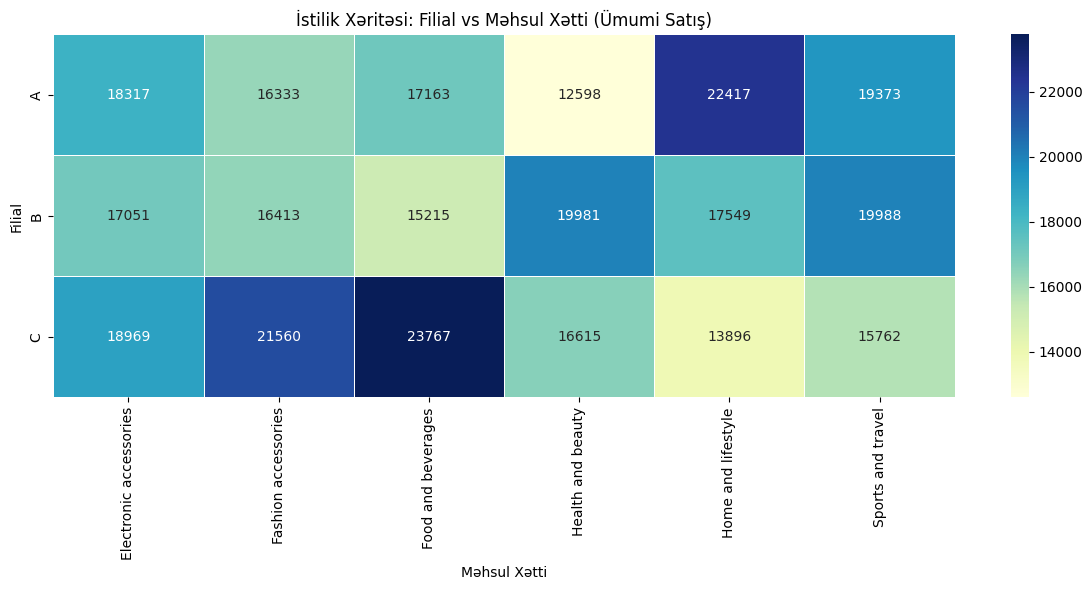

In [ ]:
pivot_branch_product = df.pivot_table(
    values='Total',
    index='Branch',
    columns='Product line',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_branch_product, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('İstilik Xəritəsi: Filial vs Məhsul Xətti (Ümumi Satış)')
plt.xlabel('Məhsul Xətti')
plt.ylabel('Filial')
plt.tight_layout()
plt.show()

Biznes Anlayislari

1. Saat 19:00 (axsam) gunun en islek saatidir (113 sifaris), ardinca saat 13:00 (nahar vaxti) gelir. Bu, filiallarin bu saatlarda elave kassa ve iscisi ile hazir olmasi lazim oldugunu gosterir.

2. Food and beverages ve Sports and travel en yuksek gelirli mehsul xetleridir, Health and beauty ise en ashagi gostericiyedir. Marketinq ve anbar strategiyalari bu meyara gore tenzimlenmelidir.

3. Butun mehsul xetlerinde menfeet marjasi sabit 5%-dir, bu da satici terefinden butun mehsullara eyni qiymetlendirme siyasetinin tetbiq edildiyini gosterir - bir mehsul digerinden daha genis menfeet getirmir.

4. C filiali, Food and beverages kateqoriyasinda diger filial-kateqoriya kombinasiyalarindan xeyli yuksek satisha (23767 dollar) malikdir, A filiali ise Home and lifestyle-da guclu performans gosterir. Bu, her filialin oz bolgesine uygun mehsul cesidlerini artirmasi ucun imkan yarada biler.